In [1]:
from ddsp import DDSP, AudioFeatureDataset
from ddsp.callbacks import BetaWarmupEpochCallback
from ddsp.synths import NoiseBandSynth, SineSynth, BendableNoiseBandSynth
from ddsp.utils import find_checkpoint

from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from lightning import Trainer

from IPython.display import Audio, display

from torch.utils.data import DataLoader, Subset, random_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import umap

torch.set_float32_matmul_precision('medium')
torch.set_default_tensor_type('torch.cuda.FloatTensor')
torch.set_default_device('cuda')

import os

experiment_root = '/home/btadeusz/code/ddsp_vae/experiments/feature_control'
models_root = os.path.join(experiment_root, 'models')
training_root = os.path.join(experiment_root, 'training')

/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [2]:
# Dataset parameters
chunk_duration = 2.0
sampling_rate = 22050
n_signal = chunk_duration * sampling_rate
batch_size = 8
n_features = 2

# Model parameters
latent_size = num_params = 2
# smoothing_kernel = 1 # regular
smoothing_kernel = 65 # reactive
max_freq = sampling_rate//2
n_filters = 512 # regular
# n_filters = 1024 # large
plateau_patience = 100000 # regular
# plateau_patience = 50 # patient
# n_sines = 100

# resampling_factor = 512 # super low
resampling_factor = 256 # mid
# resampling_factor = 128 # low
# resampling_factor = 32 # regular
# resampling_factor = 8 # detailed

# Training parameters
warmup_start = 50
warmup_end = 100
# beta = 0.006
beta = 0.001
max_epochs = 5001
learning_rate = 1e-4
capacity = 32
gru_layers = 2

adversarial_loss = True

In [3]:
from ddsp.rave_transforms import Compose, RandomPitch, RandomMute, RandomGain, RandomCompress

def get_dataset_split(dataset_path, validation_split=0.2, validation_in_training=True):
  """
  Splits the dataset into training and validation sets.
  """
  generator=torch.Generator(device='cuda')

  augmentation_pipeline = Compose([
      # RandomPitch(n_signal=n_signal, pitch_range=[0.5, 2.0], prob=0.35),
      # RandomCompress(prob=0.05),
      # RandomGain(gain_range=(-6, 3), prob=0.05),
      RandomMute(prob=0.2)
  ])

  dataset_A = AudioFeatureDataset(dataset_path=dataset_path, n_signal=n_signal, sampling_rate=sampling_rate, smoothing_kernel_size=smoothing_kernel, transform_fn=augmentation_pipeline)
  total_len = len(dataset_A)

  val_len = int(validation_split * total_len)  # 20% for validation
  indices = torch.randperm(total_len, generator=generator)

  val_indices = indices[:val_len]
  if validation_in_training:
    train_indices = indices
  else:
    train_indices = indices[val_len:]

  train_set = Subset(dataset_A, train_indices)
  val_set = Subset(dataset_A, val_indices)

  train_loader = DataLoader(train_set, batch_size, shuffle=True, num_workers=0, generator=generator)
  val_loader = DataLoader(val_set, batch_size, shuffle=False, num_workers=0, generator=generator)

  return train_loader, val_loader, dataset_A


def build_ddsp_model():
  """
  Builds the DDSP model with the specified configurations.
  """
  # nbn = NoiseBandSynth.to_config(
  #   n_filters=n_filters,
  #   fs=sampling_rate,
  # )

  bnbn = BendableNoiseBandSynth.to_config(
    n_filters=n_filters,
    fs=sampling_rate,
    resampling_factor=resampling_factor,
  )

  # sines = SineSynth.to_config(
  #   n_sines=n_sines,
  #   fs=sampling_rate,
  # )

  ddsp = DDSP(
    # synth_configs=[nbn, sines],
    synth_configs=[bnbn],
    fs=sampling_rate,
    latent_size=latent_size,
    latent_smoothing_kernel=smoothing_kernel,
    decoder_gru_layers=gru_layers,
    num_params=num_params,
    n_features=n_features,
    learning_rate=learning_rate,
    perceptual_loss_weight=0,
    plateau_patience=plateau_patience,
    capacity=capacity,
    resampling_factor=resampling_factor,
    adversarial_loss=adversarial_loss,
  ).to('cuda')

  return ddsp


def build_trainer(model_training_path, model_name):
  training_callbacks = []
  beta_warmup = BetaWarmupEpochCallback(
    beta=beta,
    start_epoch=warmup_start,
    end_epoch=warmup_end
  )
  training_callbacks.append(beta_warmup)

  best_checkpoint_callback = ModelCheckpoint(
    filename='best',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    save_last=True,
    dirpath=model_training_path
  )
  training_callbacks.append(best_checkpoint_callback)

  tb_logger = TensorBoardLogger(
    save_dir=os.path.join(model_training_path, "tb"),
    name=model_name,
    default_hp_metric=False
  )

  trainer = Trainer(
    callbacks=training_callbacks,
    max_epochs=max_epochs,
    accelerator='cuda',
    logger=tb_logger,
    log_every_n_steps=10,
    # precision=16,
  )

  return trainer


def train_on_dataset(dataset_path, model_name=None):
  """
  Trains the DDSP model on a specific dataset.
  """
  train_loader, val_loader, dataset = get_dataset_split(dataset_path)

  model = build_ddsp_model()

  model_training_path = os.path.join(training_root, model_name)
  trainer = build_trainer(model_training_path, model_name)

  ckpt = find_checkpoint(model_training_path, return_none=True, typ='last')
  print("Found ckpt: ", ckpt)
  trainer.fit(model, train_loader, val_loader, ckpt_path=ckpt)

  return model, trainer, train_loader, val_loader, dataset, model_training_path

def make_batch_from_indices(dataset, indices, device='cuda'):
  """
  Returns:
    x_audio:    [B, 1, T]
    x_features: [B, T_feat, n_features]
  """
  items = [dataset[i] for i in indices]
  a = []
  f = []
  for audio_i, feat_i in items:
    # Ensure audio has shape [1, T]
    if audio_i.ndim == 1:
      audio_i = audio_i.unsqueeze(0)
    a.append(audio_i)
    f.append(feat_i)
  x_audio    = torch.stack(a, dim=0).to(device).squeeze()
  x_features = torch.stack(f, dim=0).to(device).squeeze()
  return x_audio, x_features

In [4]:
model_name = f'noise-todos-mute0.2-auto'
dataset_path = '/mnt/mariadata/datasets/mixed-artists/processed'
model, trainer, train_loader, val_loader, dataset, training_path = train_on_dataset(dataset_path, model_name=model_name)

Loading from cache: /mnt/mariadata/datasets/mixed-artists/audio_cache_f1049e89.lmdb


/home/btadeusz/code/ddsp_vae/ddsp/audio_feature_dataset.py:176: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  audio_cpu[pos:pos+n_samps] = torch.from_numpy(a_arr)
/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.uti

Found ckpt:  /home/btadeusz/code/ddsp_vae/experiments/feature_control/training/noise-todos-mute0.2-auto/last.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/lightning/pytorch/core/optimizer.py:316: The lr scheduler dict contains the key(s) ['monitor'], but the keys will be ignored. You need to call `lr_scheduler.step()` manually in manual optimization.

  | Name                     | Type                            | Params | Mode 
-------------------------------------------------------------------------------------
0 | synths                   | ModuleList                      | 0      | train
1 | encoder                  | VariationalEncoder              | 338 K  | train
2 | decoder                  | Decoder                         | 4.3 M  | train
3 | _mr_stft_loss            | MultiResolutionSTFTLoss         | 707    | train
4 | _sliced_wasserstein_loss | MultiScaleSlicedWassersteinLoss | 0      | train
5 | _discriminator           | Discriminator                   | 2.1 M  | train
------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.
/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/lightning/pytorch/trainer/call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...


In [ ]:
import sys
sys.path.append('/home/btadeusz/code/ddsp_vae/experiments/feature_control')
from utils import examine_model

indices = np.random.randint(0, len(dataset), 8)
# indices = [238, 283, 823, 281, 258, 126, 507, 574]
print("indices:", indices)
# indices = list(range(8))
batch = make_batch_from_indices(dataset, indices, device='cuda')
examine_model(model, batch, sampling_rate=sampling_rate, path=f'/home/btadeusz/code/ddsp_vae/experiments/mute_augment/figures/{model_name}', )

In [ ]:
synth_output_path = os.path.join(models_root, f'{model_name}.ts')
! python -m cli.export --model_directory {training_path} --output_path {synth_output_path} --type last --target_fs 44100

# Prior training

In [29]:
prior_batch_size = 256

# sequence_length = 512
# embedding_dim = 8
# nhead = 2
# num_layers = 2
# quantization_channels = 16
# lr = 1e-4

sequence_length = 128
embedding_dim = 32
nhead = 8
num_layers = 4
quantization_channels = 64
lr = 1e-4

prior_epochs = 10001
dataset_stride_factor = 0.2

reinitiate = True

In [32]:

from ddsp.prior import Prior, PriorDataset
import shutil

# prior_model_name = 'morelli-for-prior-prior'
prior_model_name = f'{model_name}-prior-seq128'

# Training dir
prior_training_path = os.path.join(training_root, prior_model_name)

# Reinitiate the training path
if reinitiate:
  shutil.rmtree(prior_training_path, ignore_errors=True)
  os.makedirs(prior_training_path, exist_ok=True)


prior_dataset = PriorDataset(
  # audio_dataset_path=dataset_path,
  audio_dataset=dataset,
  encoding_model_path=synth_output_path,
  sequence_length=sequence_length+1,
  sampling_rate=sampling_rate,
  device='cuda',
  stride_factor=dataset_stride_factor
)
normalization_dict = prior_dataset.normalization_dict

generator = torch.Generator(device='cuda')
prior_train_set, prior_val_set = random_split(prior_dataset, [0.8, 0.2], generator=generator)
prior_train_loader = DataLoader(prior_train_set, batch_size=prior_batch_size, shuffle=True, generator=generator)
prior_val_loader = DataLoader(prior_val_set, batch_size=prior_batch_size, shuffle=False, generator=generator)

# latent_size = prior_dataset[0].shape[-1]

Encoding audio dataset...


### Test the prior dataset, generating the audio from random samples

In [25]:
from torch import jit
synth = jit.load(synth_output_path).to('cpu')

In [ ]:
from random import randint
from IPython.display import Audio, display

# Sample a random index from the prior dataset
random_idx = randint(0, len(prior_dataset) - 1)
sample = prior_dataset[random_idx].t().unsqueeze(0).to('cpu')  # shape: [sequence_length+1, latent_size]

# Prepare latents for the synth (shape: [1, latent_size, sequence_length+1])
# sample = sample.t().unsqueeze(0)

# latents_sample = torch.nn.functional.interpolate(latents_sample, size=int(latents_sample.shape[-1]//4), mode='nearest')
features_sample = sample[:, :-latent_size, :].permute(0, 2, 1).cuda()
latents_sample = sample[:, -latent_size:, :].permute(0, 2, 1).cuda()

with torch.no_grad():
  # synth_params = model.decoder(features_sample, latents_sample).squeeze(1)
  # audio_sample = model._synthesize(synth_params)
  audio_sample = synth.decode(sample)

# Normalize audio for playback
audio_sample_np = audio_sample.squeeze(0).detach().cpu().numpy()
audio_sample_np = audio_sample_np / max(1e-9, abs(audio_sample_np).max())

display(Audio(audio_sample_np, rate=sampling_rate*2))

### Load model

In [10]:
prior_checkpoint = find_checkpoint(prior_training_path, typ='last')
prior = Prior.load_from_checkpoint(prior_checkpoint)

/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  warnings.warn(warning.format(ret))


### Or initialize for training

In [33]:
import lightning as L
from random import randint

prior = Prior(
  latent_size=prior_dataset[0].shape[-1],
  embedding_dim=embedding_dim,
  quantization_channels=quantization_channels,
  max_len=sequence_length,
  lr=lr,
  nhead=nhead,
  num_layers=num_layers,
  normalization_dict=normalization_dict
)

prior_logger = TensorBoardLogger(prior_training_path, name=prior_model_name)

prior_callbacks = []
prior_checkpoint_callback = ModelCheckpoint(
  dirpath=prior_training_path,
  filename='best',
  monitor='val_loss',
  mode='min',
  save_top_k=1,
  save_last=True,
)
prior_callbacks.append(prior_checkpoint_callback)

from lightning.pytorch.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_acc', patience=1000, mode='max', stopping_threshold=0.99)
prior_callbacks.append(early_stopping)

prior_trainer = L.Trainer(
  callbacks=prior_callbacks,
  accelerator='cuda',
  log_every_n_steps=4,
  logger=prior_logger,
  max_epochs=prior_epochs
)

ckpt_path = find_checkpoint(prior_training_path, return_none=True, typ='last')
if ckpt_path is not None:
  print(f'Resuming training from checkpoint {ckpt_path}')


# Start training
prior_trainer.fit(
  model=prior,
  train_dataloaders=prior_train_loader,
  val_dataloaders=prior_val_loader,
  ckpt_path=ckpt_path
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Missing logger folder: /home/btadeusz/code/ddsp_vae/experiments/feature_control/training/noise-todos-mute0.2-auto-prior-seq128/noise-todos-mute0.2-auto-prior-seq128
/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:652: Checkpoint directory /home/btadeusz/code/ddsp_vae/experiments/feature_control/training/noise-todos-mute0.2-auto-prior-seq128 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                 | Type                    | Params | Mode 
-------------------------------------------------------------------------
0 | _quantizer           | MuLawEncoding           | 0      | train
1 | _dequantizer         | MuLawDecoding           | 0      | train
2 | _embedding           | Embedding               | 2.0 K  | train
3 | _encoder             | TransformerEncoder      | 2.4 M  | 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [14]:
prior_val_loss = prior_trainer.callback_metrics['val_acc']
print(f'Final validation loss: {prior_val_loss}')

Final validation loss: 0.7042540311813354


# Unconditional generation

In [15]:
from torch import jit
synth = jit.load(synth_output_path).to('cpu')

cpu


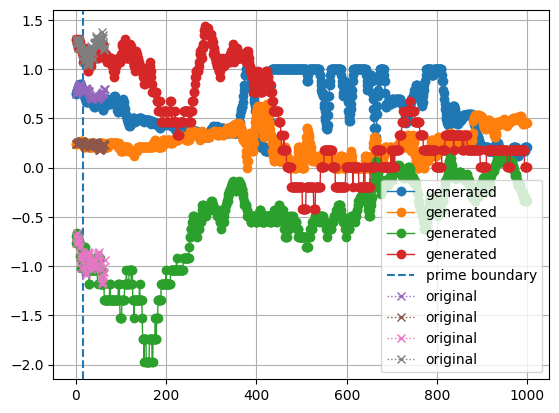

In [19]:
import torch
import matplotlib.pyplot as plt
from random import randint
from IPython.display import Audio, display

# device = "cuda" if torch.cuda.is_available() else "cpu"
# prior = prior.to(device).eval()
# synth = synth.to(device).eval()
prior = prior.cuda()
prior.eval()

num_steps = 1000
prime_len = sequence_length // 4

orig_sequence = prior_dataset[randint(0, len(prior_dataset)-1)].to('cuda')   # [L, D_feat + D_lat]
# orig_sequence = torch.zeros_like(orig_sequence) / 4  # prime of zeros
prime = orig_sequence[:prime_len]
# prime of zeros


with torch.no_grad():
  sequence = prior.generate(prime, num_steps, 1.0)                            # [T, D_total]

# D_LATENTS = synth.pretrained.latent_size
# D_FEATS = sequence.size(-1) - D_LATENTS

# features = sequence[:, :D_FEATS].unsqueeze(0).to('cpu')
# latents  = sequence[:, -D_LATENTS:].unsqueeze(0).to('cpu')
latents = sequence.unsqueeze(0).permute(0, 2, 1).to('cpu')
# features = sequence[:, n_features:]
# latents = sequence[:, :n_features]
# latents = torch.cat([features, latents], dim=-1).unsqueeze(0).permute(0, 2, 1).to('cpu')

print(latents.device)
with torch.no_grad():
  audio = synth.decode(latents)

# plot a latent dim and mark prime boundary
gen_lat_0 = sequence.detach().cpu().numpy()
orig_lat_0 = orig_sequence.detach().cpu().numpy()

plt.plot(gen_lat_0, label='generated', marker='o', linewidth=1)
plt.axvline(x=prime_len-1, linestyle='--', label='prime boundary')
plt.plot(orig_lat_0, linestyle=':', label='original', marker='x', linewidth=1)
plt.legend(); plt.grid(True); plt.show()

# audio playback
fs = prior_dataset._sampling_rate
audio_np = audio.squeeze(0).detach().cpu().numpy()
audio_np = audio_np / max(1e-9, abs(audio_np).max())
display(Audio(audio_np, rate=fs))

## Export prior model

In [17]:

prior_model_path = os.path.join(models_root, f'{prior_model_name}.ts')
!python -m cli.export --model_directory {training_path} --prior_directory {prior_training_path} --output_path {prior_model_path} --type best --target_fs 44100

print(f'Model saved at {prior_model_path}')

exporting model from checkpoint: /home/btadeusz/code/ddsp_vae/experiments/feature_control/training/noise-todos-mute0.2-auto/best.ckpt
exporting prior model from checkpoint:  /home/btadeusz/code/ddsp_vae/experiments/feature_control/training/noise-todos-mute0.2-auto-prior/best.ckpt
/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  warnings.warn(warning.format(ret))
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
